Dataset count:
attack_label
3    20000
0      837
Name: count, dtype: int64

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           3       1.00      1.00      1.00      4001

    accuracy                           1.00      4168
   macro avg       1.00      1.00      1.00      4168
weighted avg       1.00      1.00      1.00      4168

Confusion Matrix:
[[ 167    0]
 [   0 4001]]


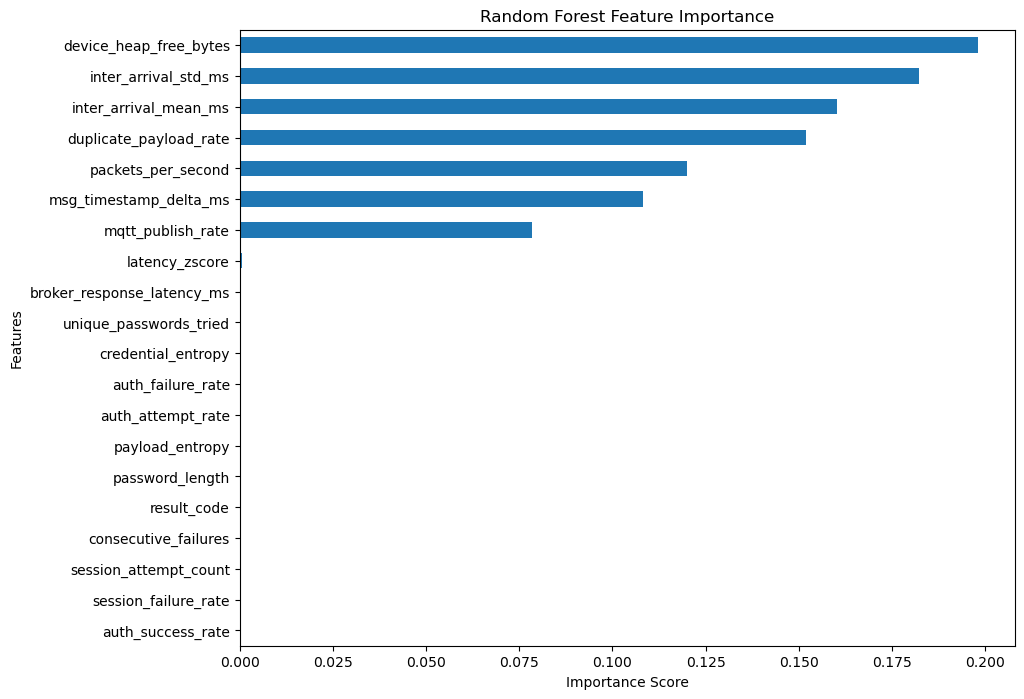

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load datasets
normal = pd.read_csv("dataset_Normal.csv")
replay = pd.read_csv("dataset_Replay.csv")

# Merge datasets
df = pd.concat([normal, replay], ignore_index=True)

print("Dataset count:")
print(df["attack_label"].value_counts())

# Remove non-numeric columns
drop_cols = [
    "timestamp",
    "attack_type",
    "src_ip",
    "target_ip"
]

X = df.drop(columns=drop_cols + ["attack_label"])
y = df["attack_label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Accuracy as percentage
acc = accuracy_score(y_test, pred) * 100
print(f"\nAccuracy: {acc:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

# Feature importance graph
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()